<a href="https://colab.research.google.com/github/memo124/Pr-ctica-de-Redes-Neuronales-Dise-o-de-Arquitecturas-Densas/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica de Redes Neuronales: Diseño de Arquitecturas Densas

## Equipo y roles

- **Guillermo Andres Minero Alfaro:** Especialista en Datos y Arquitecto de los modelos A y B.
- **Ruben Armando Vigil Mejia:** Arquitecto del modelo C y Analista de Métricas.

En esta primera parte preparamos los datos y comparamos una red minimalista con una red profunda.

## 1. Preparación de los datos

Usaremos el dataset de cáncer de mama incluido en Scikit-learn. Es un problema de clasificación binaria. Los datos se separan en entrenamiento, validación y prueba. El conjunto de prueba se reserva para el final.

In [1]:
%matplotlib inline

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from IPython.display import Markdown, display
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Semillas para poder repetir el experimento.
np.random.seed(42)
tf.random.set_seed(42)

# Cargar el dataset.
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Separar primero el 20 % para la prueba final.
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Separar una parte del entrenamiento para validación.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=42, stratify=y_train_full
)

# Ajustar el escalador solo con los datos de entrenamiento.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f'Dataset completo: {X.shape}')
print(f'Entrenamiento: {X_train_scaled.shape}')
print(f'Validación: {X_val_scaled.shape}')
print(f'Prueba: {X_test_scaled.shape}')

I0000 00:00:1790305443.565897  872462 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1790305445.671950  872462 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Dataset completo: (569, 30)
Entrenamiento: (364, 30)
Validación: (91, 30)
Prueba: (114, 30)


## 2. Modelo A: El Minimalista

Tiene una sola capa oculta de 8 neuronas. ReLU ayuda a aprender relaciones no lineales y Sigmoid entrega una probabilidad entre 0 y 1 para la clasificación binaria. Este modelo sirve como punto de comparación sencillo.

In [2]:
model_A = Sequential([
    tf.keras.Input(shape=(X_train_scaled.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_A.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_A.summary()
history_A = model_A.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100, batch_size=32, verbose=0
)
print('Modelo A entrenado correctamente.')

E0000 00:00:1790305447.373442  872462 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257 (1.00 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

Modelo A entrenado correctamente.


## 3. Modelo B: El Profundo

Tiene tres capas ocultas de 64, 128 y 64 neuronas. Su mayor cantidad de neuronas le permite aprender patrones más complejos, pero también aumenta el riesgo de memorizar los datos de entrenamiento y presentar overfitting.

In [3]:
model_B = Sequential([
    tf.keras.Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_B.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_B.summary()
history_B = model_B.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150, batch_size=32, verbose=0
)
print('Modelo B entrenado correctamente.')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,625 (72.75 KB)

 Trainable params: 18,625 (72.75 KB)

 Non-trainable params: 0 (0.00 B)

Modelo B entrenado correctamente.


## 4. Curvas de aprendizaje

La línea vertical marca la época con el menor `val_loss`. Después de ese punto puede aparecer overfitting si el error de entrenamiento sigue bajando mientras el error de validación aumenta.

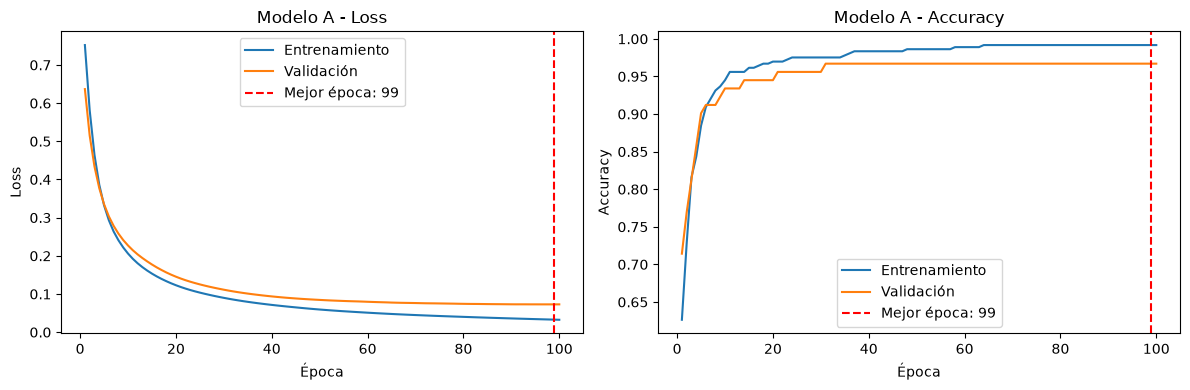

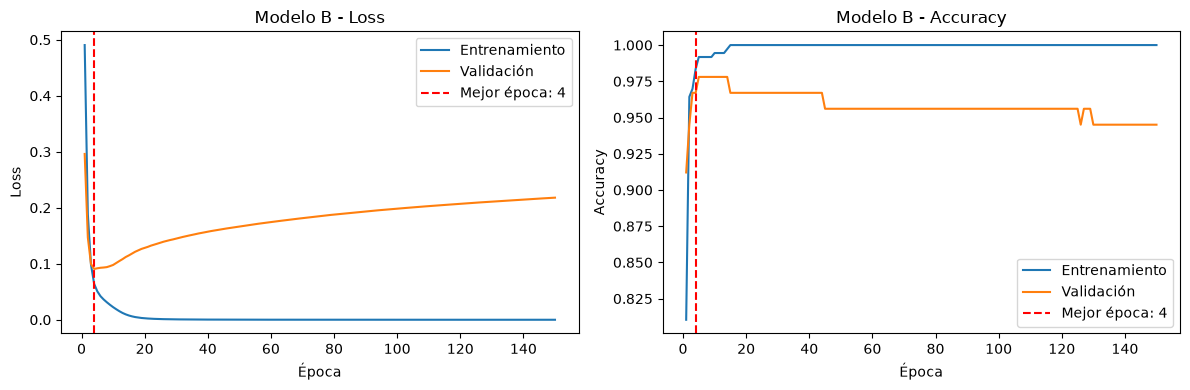

Mejor época del Modelo A según val_loss: 99
Mejor época del Modelo B según val_loss: 4


In [4]:
def plot_history(history, model_name):
    best_epoch = int(np.argmin(history.history['val_loss'])) + 1
    epochs = range(1, len(history.history['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history.history['loss'], label='Entrenamiento')
    axes[0].plot(epochs, history.history['val_loss'], label='Validación')
    axes[0].axvline(best_epoch, color='red', linestyle='--', label=f'Mejor época: {best_epoch}')
    axes[0].set_title(f'{model_name} - Loss')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(epochs, history.history['accuracy'], label='Entrenamiento')
    axes[1].plot(epochs, history.history['val_accuracy'], label='Validación')
    axes[1].axvline(best_epoch, color='red', linestyle='--', label=f'Mejor época: {best_epoch}')
    axes[1].set_title(f'{model_name} - Accuracy')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    return best_epoch

best_epoch_A = plot_history(history_A, 'Modelo A')
best_epoch_B = plot_history(history_B, 'Modelo B')
print(f'Mejor época del Modelo A según val_loss: {best_epoch_A}')
print(f'Mejor época del Modelo B según val_loss: {best_epoch_B}')

## 5. Evaluación final de los modelos A y B

Ahora usamos por primera vez el conjunto de prueba. Esto permite medir el rendimiento con datos que no participaron en el entrenamiento ni en la selección visual de la mejor época.

In [5]:
test_loss_A, test_accuracy_A = model_A.evaluate(X_test_scaled, y_test, verbose=0)
test_loss_B, test_accuracy_B = model_B.evaluate(X_test_scaled, y_test, verbose=0)

results = pd.DataFrame({
    'Modelo': ['A - Minimalista', 'B - Profundo'],
    'Mejor época (val_loss)': [best_epoch_A, best_epoch_B],
    'Test Loss': [test_loss_A, test_loss_B],
    'Test Accuracy': [test_accuracy_A, test_accuracy_B]
})
display(results.round(4))

,Modelo,Mejor época (val_loss),Test Loss,Test Accuracy
0,A - Minimalista,99,0.1022,0.9649
1,B - Profundo,4,0.2032,0.9649


## 6. Análisis de overfitting

In [6]:
winner = 'Modelo A' if test_accuracy_A >= test_accuracy_B else 'Modelo B'
analysis = f'''
- En el **Modelo A**, el menor `val_loss` se obtuvo en la época **{best_epoch_A}**.
- En el **Modelo B**, el menor `val_loss` se obtuvo en la época **{best_epoch_B}**. Después de esta época, una separación creciente entre entrenamiento y validación indica overfitting.
- El Modelo B tiene mayor capacidad y puede memorizar con más facilidad un dataset pequeño.
- En la prueba final, el Modelo A obtuvo **{test_accuracy_A:.2%}** de accuracy y el Modelo B obtuvo **{test_accuracy_B:.2%}**.
- Según el accuracy de prueba de esta ejecución, **{winner}** consiguió el mejor resultado. También deben revisarse las curvas de loss y la diferencia entre entrenamiento y validación.

No usamos `EarlyStopping` en estos dos modelos porque queremos observar el overfitting. Esa técnica se aplicará en el Modelo C.
'''
display(Markdown(analysis))


- En el **Modelo A**, el menor `val_loss` se obtuvo en la época **99**.
- En el **Modelo B**, el menor `val_loss` se obtuvo en la época **4**. Después de esta época, una separación creciente entre entrenamiento y validación indica overfitting.
- El Modelo B tiene mayor capacidad y puede memorizar con más facilidad un dataset pequeño.
- En la prueba final, el Modelo A obtuvo **96.49%** de accuracy y el Modelo B obtuvo **96.49%**.
- Según el accuracy de prueba de esta ejecución, **Modelo A** consiguió el mejor resultado. También deben revisarse las curvas de loss y la diferencia entre entrenamiento y validación.

No usamos `EarlyStopping` en estos dos modelos porque queremos observar el overfitting. Esa técnica se aplicará en el Modelo C.


---
## Continuación del Integrante 2

A partir de aquí, Ruben desarrollará el **Modelo C (Optimizado)** usando Dropout, Adam, regularización y EarlyStopping. Después realizará la comparación final de los tres modelos y el análisis crítico grupal.